In [ ]:
%load_ext autoreload
%autoreload 2

try:
    import pandas as pd
    import anndata
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from src.beta_regression import BetaRegressionAlphaBeta
    from src.util import generate_diploid_methylation_states, hardy_weinberg_probabilities, orthogonalize_power_term, wright_F_statistic
    from src.clonal_evolution import ClonalSim
    from scipy import stats
    from functools import partial
    from src import plot_lineage_evolution, plot_lineage_dendrogram, plot_population_metrics

    # Custom color palette
    COLORS_LARGE_PALLETE = [
        '#0F4A9C', '#3F84AA', '#C9EBFB', '#8DB5CE', '#C594BF', '#DFCDE4',
        '#B51D8D', '#6f347a', '#683612', '#B3793B', '#357A6F', '#989898',
        '#CE778D', '#7F6874', '#E09D37', '#FACB12', '#2B6823', '#A0CC47',
        '#77783C', '#EF4E22', '#AF1F26'
    ]


    # Initial CpG distribution parameters
    N_POP = 100         # --> Arbitrary, best to keep low
    N_CPGS = 1000       # --> Determined by methylation array chosen
    N_LINEAGES = 1000   # --> Biologically determined, known
    S = 0.05            # --> Biologically determined, unknown
    MIN_POPULATION_THRESH, MAX_POPULATION_THRESH = 0.15, 0.20

    # Biologically determined, unknown
    # allele_methylation_generator = partial(wright_F_statistic, F=1)
    allele_methylation_generator = hardy_weinberg_probabilities

    # CHIP Parameters
    INDIVIDUAL_INDEX = 0 # Arbitrary
    TAU = 1.4              # Biologically determined, known (Tau = 1/s)
    MU = 5e-8              # Biologically determined, known
    # N = 100000           # Biologically determined, known
    N = 1000              # Biologically determined, known
    MAX_VARIANTS = 10
    NO_VARIANTS = 0

    p_sym_renewal = 0.5
    p_asym        = 0.00
    p_diff   = 0.5

    DIVISION_DIST_GENERATOR = lambda : (p_sym_renewal, p_asym, p_diff) # Division probabilities: SS, SD, DD


    sns.set_theme(style="whitegrid", palette="pastel")

    is_initialized=False
except Exception as e:
    raise EnvironmentError("Could not initialize simulation environment:\n", e)

## Methylation Initialization: Generation Scotland Beta Regression Model

Before any simulation can run, each lineage needs a starting methylation profile - a vector of Beta values across CpG sites. This cell constructs that profile from a per-CpG Beta regression model fitted to the Generation Scotland (GenScot) cohort.

### The model
`BetaRegressionAlphaBeta` is a per-CpG regression model that predicts the shape parameters (α, β) of a Beta distribution over methylation levels as a function of age and sex. Each of the ~750k CpGs has its own four-coefficient vectors stored in `gamma_alpha` and `gamma_beta`. Evaluated at a given age and sex, the model produces a Beta distribution whose mean and variance describe the *population-level* methylation distribution at that covariate value.

_Note: the regression model is being actively developed to incorporate structural mQTLs_

### Age parameterization
Age is not used directly - it is first mapped to a bounded, orthogonalized basis:
- `t_linear = (age − 13.5) / (122.5 − 13.5)` - scales age to [0, 1] between sexual maturity and maximum lifespan
- `t_power = t_linear²` - adds a nonlinear aging component
- `t_power_orth` - `t_power` orthogonalized against `t_linear` to remove collinearity before regression

The model is evaluated at age 18 here to get the *young-adult* CpG distribution, used to initialize lineage methylation near the onset of adult hematopoiesis.

### Lineage initialization (single-level, simplified)
In this notebook each of the 1,000 lineages is initialized with its own independent Beta draw from the population posterior. One sample per lineage, one level of stochasticity. This treats every lineage as if it were a different person sampled from GenScot, which overestimates between-lineage dispersion within a single individual. The biologically accurate two-level hierarchical approach (individual mean -> lineage probabilities -> diploid states) is introduced in the Transition section at the end of this notebook.


In [1]:
genscot_regression_df = pd.read_csv('./data/genscot_regression_results.tsv', index_col='cpg_name', sep='\t')

# NOTE: An improvement of this model (a structurally constrained beta distribution that can handle mQTLs)
# is actively being developed. This version may change
model = BetaRegressionAlphaBeta()

model.gamma_alpha = np.array([
    genscot_regression_df['exponential_alpha_intercept'],
    genscot_regression_df['exponential_alpha_age_linear'],
    genscot_regression_df['exponential_alpha_age_power'],
    genscot_regression_df['exponential_alpha_sex']
])

model.gamma_beta = np.array([
    genscot_regression_df['exponential_beta_intercept'],
    genscot_regression_df['exponential_beta_age_linear'],
    genscot_regression_df['exponential_beta_age_power'],
    genscot_regression_df['exponential_beta_sex']
])

age_grid = np.array([18, 85])

a_young = 13.5
l = 122.5
n = 2.0

t_linear = (age_grid - a_young) / (l - a_young)
t_power = t_linear**n

t_power_orth, _ = orthogonalize_power_term(t_linear, t_power)

X_profile = np.column_stack([
    np.ones_like(age_grid),
    t_linear,
    t_power_orth,
    np.full_like(age_grid, 0.5)
])

# Get per-CpG statistical moments for young (18) and old (90) individuals
moments = model.predict_moments(X_profile, X_profile)

alphas = moments['alpha']
betas = moments['beta']

def beta_rvs_multi(a, b, s):
    # a, b shape (n,) -> broadcast to (n, s)
    return np.random.beta(a[:, None], b[:, None], size=(len(a), s))

# 1. Sample 1000 different target probabilities for 1000 lineages
# Shape: (N_cpgs, 1000)
beta_rvs_result_jittered = beta_rvs_multi(alphas[0], betas[0], s=N)

# 2. Transpose to match (n_individuals, n_cpgs) where n_individuals = n_lineages
# Shape: (1000, N_cpgs)
lineage_probs = beta_rvs_result_jittered.T

# 3. Generate 1 cell per "individual" (lineage)
# This creates a (1, 1000, N_cpgs) tensor
diploid_tensor = generate_diploid_methylation_states(
    lineage_probs,
    distribution_func=hardy_weinberg_probabilities,
    n_cells=1
)[0, :, :]

# 4. Collapse to your starting beta_matrix_t0
# Shape: (1000, N_cpgs)
methylation_adata = anndata.AnnData(X=diploid_tensor)
methylation_adata.var.index = genscot_regression_df.index
methylation_adata

AnnData object with n_obs × n_vars = 1000 × 751374

## Demo 1: Neutral Evolution

### Design

| Parameter | Value | Rationale |
|---|---|---|
| `N_init` | 1,000 | Representative HSC lineage count |
| `p_ss = p_sd = p_dd` | 0.33 each | Perfectly balanced - zero net growth bias |
| `max_variants` | 0 | Mutations disabled; pure stochastic drift only |
| `tau` | 1.0 yr | ~1 HSC division per year (adult steady-state) |

### What it simulates
All 1,000 lineages start with equal cell counts and perfectly balanced division symmetry. With `p_ss = p_dd = 0.33`, each lineage has zero net growth advantage - the population evolves entirely by stochastic drift. Random division outcomes cause some lineages to gain cells by chance and others to lose them, leading to gradual extinction of some clones and drift-driven expansion of others. This is the **biological null model**: clonal hematopoiesis driven by chance alone, not selection.

### What to look for
- The Muller plot shows gradual, random lineage loss with no clone achieving rapid dominance
- No "selective sweep", i.e. no single band expands explosively at the expense of others
- Population metrics (Gini coefficient, alive lineage count) evolve along smooth, predictable neutral-drift trajectories


Neutral evolution simulation complete.
  Final time: 80.1 years
  Lineages: 1000
  Mutated lineages at endpoint: 0


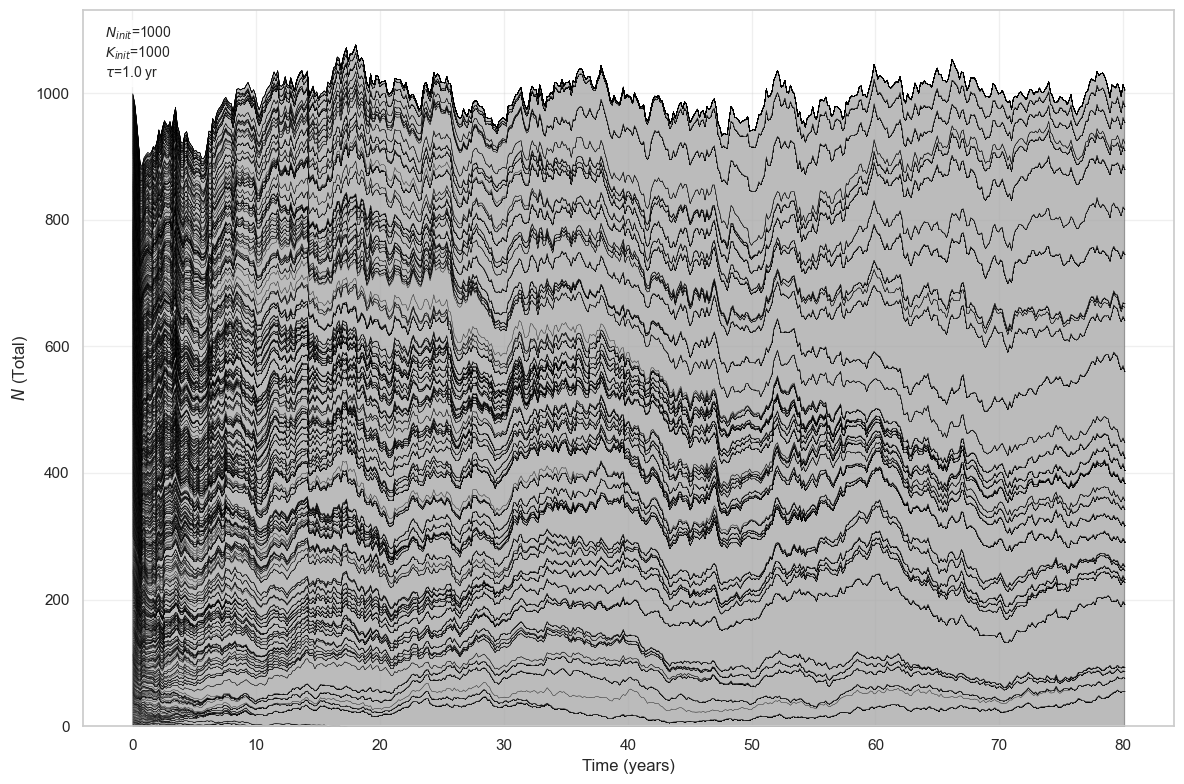

<Figure size 640x480 with 0 Axes>

In [2]:

import matplotlib.pyplot as plt


assert sum([p_sym_renewal, p_diff, p_asym]) == 1

sim_neutral = ClonalSim(
    N_init=N,
    adata=methylation_adata,
    K_init=N,
    p_sym_renewal=0.33,
    p_asym=0.33,
    p_diff=0.33,
    tau=1,
    dt=0.15,
    division_dist=DIVISION_DIST_GENERATOR,
    mu=MU,
    symmetry_drift_alpha=1000.0,
    max_variants=NO_VARIANTS,
)

time_points = list(range(20, 85, 5))  # 10..80 years
results_neutral = sim_neutral.run_simulation(time_points)

print("Neutral evolution simulation complete.")
print(f"  Final time: {sim_neutral.current_time:.1f} years")
print(f"  Lineages: {sim_neutral.N_init}")
print(f"  Mutated lineages at endpoint: {results_neutral[time_points[-1]]['mutated_lineages']}")
plot_lineage_evolution(
    sim=sim_neutral,
    timepoints_to_evaluate=None,
    min_proportion=1,
    max_lineages=10000,
    shuffle=True
)
plt.suptitle("Demo 1: Neutral Evolution")
plt.tight_layout()
plt.show()


### Population Diversity Metrics

Three built-in metric specs capture the neutral drift process. Each has the signature `(counts, sim, t) -> (value, y_label, y_lims_dict)` and can be passed directly to `plot_population_metrics`. You can define custom metrics with the same signature as lambdas.

| Metric | Definition | Neutral expectation |
|---|---|---|
| `N_over_s_spec` | `Σ(counts) · τ` - effective drift scale | Constant at steady-state niche capacity |
| `nonzero_spec` | `Σ(counts > 0)` - surviving clone count | Decays as `N · √(τ / πt)` (Brownian absorption at 0) |
| `gini_spec` | Gini coefficient on clone-size distribution | Rises monotonically from 0 toward 1 |

**Theoretical neutral trajectory.** Given initial pool size $n_0$, the probability that a lineage is still alive at time $t$ is approximately:

$$P(\text{alive at } t) \approx \frac{n_0}{\sqrt{\pi t / \tau}}$$

So the expected number of surviving lineages from $N$ independent ones is:

$$E[\text{alive at } t] = N \cdot \sqrt{\frac{\tau}{\pi t}}$$

This can be overlaid on the `nonzero_spec` panel to verify the simulation matches the analytical null. Any cohort whose empirical lineage-loss curve falls *above* this line - i.e., fewer clones go extinct than expected - is evidence that positive selection is maintaining diversity.


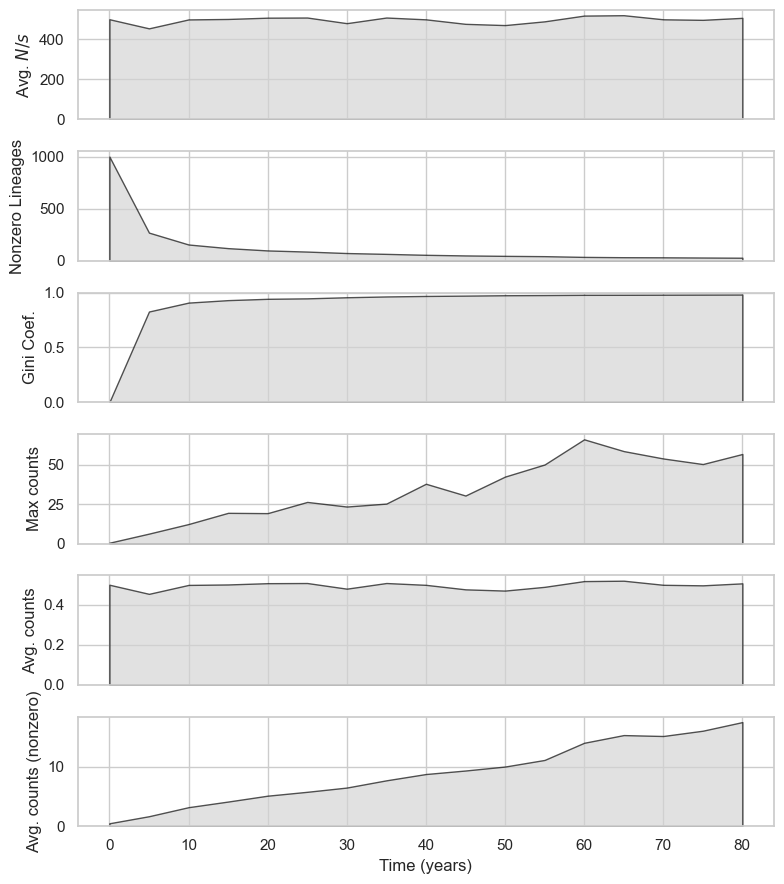

In [3]:
from src.simulation_plotting import N_over_s_spec, nonzero_spec, gini_spec

max_clone_size = lambda counts, sim, t: np.max(counts), 'Max counts', {}
avg_clone_size = lambda counts, sim, t: np.mean(counts), 'Avg. counts', {}
avg_nonzero_clone_size = lambda counts, sim, t: np.mean(counts[counts > 0]), 'Avg. counts (nonzero)', {}

plot_population_metrics(sim_neutral,
                        range(0, 85, 5),
                        metric_specs=[
                            N_over_s_spec,
                            nonzero_spec,
                            gini_spec,
                            max_clone_size,
                            avg_clone_size,
                            avg_nonzero_clone_size],
                        figsize_per_panel=(8, 1.5))
plt.show()

### Demo 1 Takeaways

**Neutral drift is slow, noisy, and irreversible.** Over 80 years, the 1,000-lineage pool loses a predictable fraction of its diversity through random division outcomes alone. Key observations:

- **Lineage extinction is permanent.** Once a lineage's count reaches 0, it cannot recover. The surviving lineage count should follow `N · √(τ/πt)` - compare the `nonzero_spec` panel against this formula as a sanity check on simulation calibration.
- **No single clone dominates.** With `p_ss = p_dd`, the largest clone grows only as `O(√t)`. No explosive expansion is possible under neutral drift alone.
- **Gini rises, but gently.** The clone-size distribution broadens slowly. A Gini of ~0.3–0.5 at age 80 under neutral drift is the reference level that any real CHIP-positive sample must exceed to be called evidence of selection.
- **This is the null model for CHIP detection.** Any individual whose clone-size or methylation-variance trajectory significantly exceeds this baseline is a candidate for positive selection. Notebook 02 operationalises this by fitting the variance trajectory across a whole cohort and comparing it to the neutral prediction.


## Demo 2: Clonal Expansion

### Design

| Parameter | Value | Rationale |
|---|---|---|
| Background `p_ss / p_dd` | 0.50 / 0.50 | Near-neutral, no net growth bias |
| Mutant `p_ss` | 0.575 | Strong self-renewal advantage |
| Mutant `p_sd` | 0.05 | Small asymmetric component |
| Mutant `p_dd` | 0.425 | Net fitness `r = p_ss − p_dd ≈ 0.15/yr` |
| Mutant injection time | `t = 15` yr | Via `event_fn` hook |
| Mutant initial count | 5 cells | Realistically small founding event |
| `tau` | 0.75 yr | Slightly faster turnover than Demo 1 |
| `max_variants` | 1 | Exactly one mutant lineage permitted |

The mutant is injected via the `event_fn` hook: a function called at every timestep that checks whether the current time is close enough to the target injection time. Its initial methylation profile is copied from a randomly chosen background lineage - a realistic model of a somatic mutation arising in an existing clone. The downstream cells then examine whether the resulting clonal expansion leaves a detectable signature in bulk methylation statistics.

### What it simulates
A single mutant with a net self-renewal advantage (`p_ss > p_dd`) competes with background lineages for the same niche capacity `K`. Because the niche is zero-sum, every cell the mutant gains displaces a background cell. The result is a classic logistic selective sweep: slow and stochastic at low VAF, then rapid and deterministic once drift is overcome, then saturating at niche capacity.

### What to look for
- The Muller plot shows a single colored band (the mutant) expanding while the gray background contracts
- The mutant trajectory approximates a logistic growth curve
- The bulk methylation histogram narrows and shifts at the final timepoint as the dominant clone's profile is over-represented
- The variance ratio `v/v₀ > 1`, indicating greater clonal concentration than at baseline
- `diagnose_simulation_assumptions` shows variance inflation > 1× at the last timepoint - a hallmark of clonal structure in bulk methylation data

*Since the simulation is stochastic, re-run if the mutant is lost by chance at low count.*


 N/s : 750.0
  [t=15.0] Mutant lineage added (id=1000)
Clonal expansion simulation complete.
  Final time: 80.2 years
  Total lineages (incl. mutant): 1000
  Mutated lineages at t=80: 1


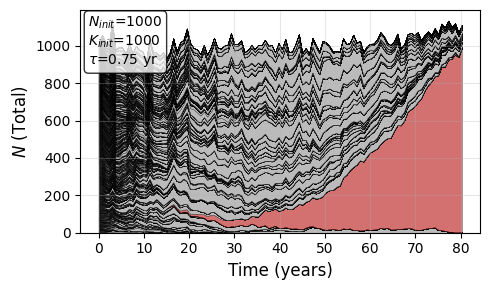

<Figure size 640x480 with 0 Axes>

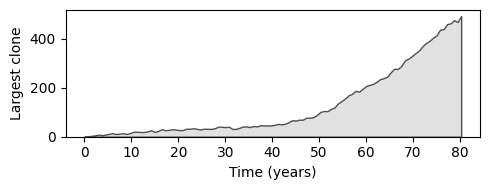

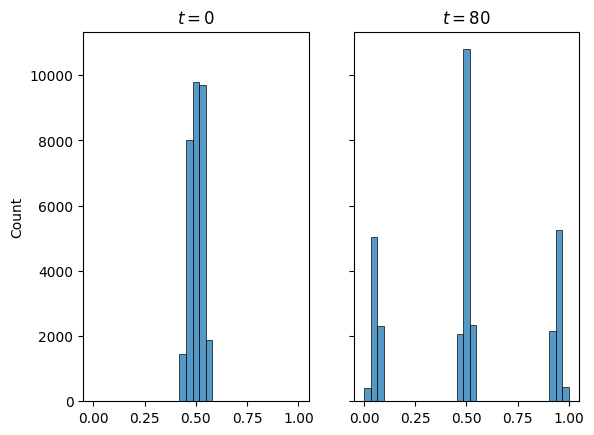

In [4]:
def add_mutant_at_t20(sim: ClonalSim, t: np.float32):
    """Event hook: add a mutant lineage with p_ss=0.40, p_dd=0.27 at t=20."""
    dt = float(np.min(sim.tau)) if sim.dt is None else sim.dt
    if abs(t - 15.0) < dt  * 0.5:
        parent_index = np.random.choice(np.arange(diploid_tensor.shape[0]), size=1)
        methylation_row = diploid_tensor[parent_index]
        mutant_id = sim.add_lineage(p_ss=0.575, p_sd=0.05, p_dd=0.425,
                                    a=1.0, initial_count=5.0,
                                    tau=2,
                                    color='#C84D4C',
                                    parent_id=parent_index,
                                    methylation_row=methylation_row)
        print(f"  [t={t:.1f}] Mutant lineage added (id={mutant_id})")


TAU = 0.75
N = 1000
print(f" N/s : {N * TAU}")

sim_clonal = ClonalSim(
    N_init=N,
    adata=methylation_adata,
    p_sym_renewal=p_sym_renewal,
    p_asym=p_asym,
    p_diff=p_diff,
    tau=TAU,
    mu=0,
    division_dist=DIVISION_DIST_GENERATOR,
    symmetry_drift_alpha=1000.0,
    max_variants=1,
    event_fn=add_mutant_at_t20,
    # dt=0.05,
    # p_m_to_u=0.3,
    # p_u_to_m=0.1
)

time_points_clonal = list(range(10, 85, 5))
results_clonal = sim_clonal.run_simulation(time_points_clonal)

print("Clonal expansion simulation complete.")
print(f"  Final time: {sim_clonal.current_time:.1f} years")
print(f"  Total lineages (incl. mutant): {sim_clonal.N_init}")
print(f"  Mutated lineages at t=80: {results_clonal[80]['mutated_lineages']}")
plt.style.use('default')

plot_lineage_evolution(
    sim=sim_clonal,
    min_proportion=0,
    max_lineages=N*10,
    shuffle=True,
    figsize=(5, 3)
)
plt.suptitle("Demo 2: Clonal Expansion (mutant p_ss=0.40, p_dd=0.27 added at t=20)")
plt.tight_layout()
plt.show()

max_clone_size = lambda counts, sim, t: np.max(counts), 'Largest clone', {}
# avg_clone_size = lambda counts, sim, t: np.mean(counts), 'Avg. counts', {}

plot_population_metrics(sim_clonal,
                        sim_clonal.time_history,
                        metric_specs=[
                            max_clone_size,
                           ],
                        figsize_per_panel=(5, 2))
plt.show()


beta_matrix_t0 = sim_clonal.get_methylation_matrix_at_time(0)
counts_t0 = sim_clonal.counts_history[0]
counts_tlast = sim_clonal.counts_history[-1]
beta_matrix_tlast = sim_clonal.get_methylation_matrix_at_time(time_points_clonal[-1])

expected_means = alphas[0] / (alphas[0] + betas[0])

# Define the mask based on the population 'truth'
mean_mask = np.logical_and(expected_means > 0.45,
                               expected_means < 0.55)

beta_matrix_t0 = beta_matrix_t0[:, mean_mask]
beta_matrix_tlast = beta_matrix_tlast[:, mean_mask]


fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)
sns.histplot(np.average(beta_matrix_t0,    weights=counts_t0, axis=0).flatten(),
             bins=np.linspace(0, 1, 32), ax=ax[0])
ax[0].set_title("$t=0$")
sns.histplot(np.average(beta_matrix_tlast, weights=counts_tlast, axis=0).flatten(),
             bins=np.linspace(0, 1, 32), ax=ax[1])
ax[1].set_title(f"$t={time_points_clonal[-1]}$")
plt.show()


Number of lineages: 1000
 Largest lineage: 0.5
Number of lineages: 1000
 Largest lineage: 8.895651595340212
Number of lineages: 1000
 Largest lineage: 15.016378961180687
Number of lineages: 1000
 Largest lineage: 19.233260260132656
Number of lineages: 1001
 Largest lineage: 28.925805211627726
Number of lineages: 1001
 Largest lineage: 29.951720767529128
Number of lineages: 1001
 Largest lineage: 38.97461540427326
Number of lineages: 1001
 Largest lineage: 41.87161960966314
Number of lineages: 1001
 Largest lineage: 46.07582321748806
Number of lineages: 1001
 Largest lineage: 66.00731003361386
Number of lineages: 1001
 Largest lineage: 88.58894327217212
Number of lineages: 1001
 Largest lineage: 145.55971284596518
Number of lineages: 1001
 Largest lineage: 207.10074680026847
Number of lineages: 1001
 Largest lineage: 245.41629094186806
Number of lineages: 1001
 Largest lineage: 329.590804250256
Number of lineages: 1001
 Largest lineage: 413.83123444873166
Number of lineages: 1001
 Large

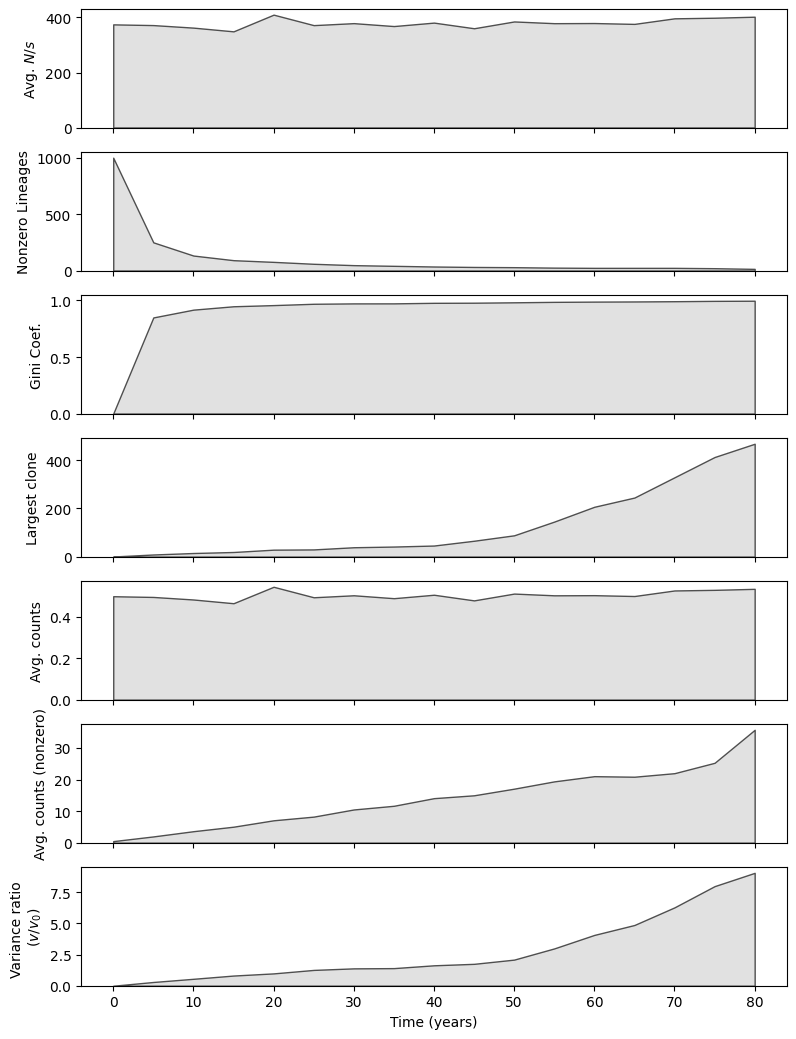

In [5]:
from src.simulation_plotting import N_over_s_spec, nonzero_spec, gini_spec

def get_variance_ratio(counts, sim, t, cpg_mask, bm_t0, bm_t):
    counts_t0 = sim.counts_history[0]
    counts_t = counts
    print(f"Number of lineages: {len(counts_t)}")
    print(f" Largest lineage: {np.max(counts_t)}")

    bm_t0 = bm_t0[:, cpg_mask]
    bm_t = bm_t[:, cpg_mask]
    bm_t = bm_t[:len(counts_t)]

    weighted_avg_t0 = np.average(bm_t0, weights=counts_t0, axis=0)
    weighted_avg_t = np.average(bm_t, weights=counts_t, axis=0)
    var_ratio = np.std(weighted_avg_t) / np.std(weighted_avg_t0)

    return var_ratio - 1


var_ratio = lambda counts, sim, t: get_variance_ratio(counts, sim, t, cpg_mask=mean_mask,
                                                      bm_t0=sim.get_methylation_matrix_at_time(0),
                                                      bm_t=sim.get_methylation_matrix_at_time(time_points_clonal[-1])), 'Variance ratio \n($v/v_0$)', {}

time_points_clonal = list(range(0, 85, 5))
plot_population_metrics(sim_clonal,
                        time_points_clonal,
                        metric_specs=[
                            N_over_s_spec,
                            nonzero_spec,
                            gini_spec,
                            max_clone_size,
                            avg_clone_size,
                            avg_nonzero_clone_size,
                            var_ratio],
                        figsize_per_panel=(8, 1.5))
plt.show()

In [6]:


import numpy as np
from scipy.special import erf

def infer_clonality_from_variance(averaged_vec, sigma_baseline_sq=None, v_t0=None, N_t0=None):
    """
    Estimates clonal metrics from the variance of the averaged methylation profile.

    Parameters:
    averaged_vec: The 1D array of weighted average methylation values.
    sigma_baseline_sq: The variance of a single lineage (if known).
    v_t0: The variance of the t=0 averaged profile.
    N_t0: The number of lineages at t=0.
    """
    v_obs = np.var(averaged_vec)

    # Calculate Simpson Index (D)
    if sigma_baseline_sq:
        simpson_hat = v_obs / sigma_baseline_sq
    elif v_t0 and N_t0 :
        simpson_hat = v_obs / (v_t0 * N_t0)
    else:
        raise ValueError("Need either single-lineage variance or t=0 baseline info.")

    # 1. Effective Number of Lineages
    n_eff = 1 / simpson_hat

    # 2. Coefficient of Variation of weights (squared)
    # Using the relationship: Var_ratio = 1 + CV^2
    # This assumes we are comparing to an 'equal weight' state of N lineages
    if N_t0:
        cv_sq = (simpson_hat * N_t0) - 1
        cv_sq = max(0, cv_sq) # Handle noise

        # 3. Estimated Gini (assuming Lognormal distribution)
        sigma_log = np.sqrt(np.log(1 + cv_sq))
        gini_hat = erf(sigma_log / 2)
    else:
        gini_hat = None

    # 4. Max Clone Size Estimate (Lower bound)
    p_max_hat = np.sqrt(simpson_hat)

    return {
        "estimated_simpson": simpson_hat,
        "estimated_gini": gini_hat,
        "estimated_p_max": min(1.0, p_max_hat),
        "effective_lineage_count": n_eff
    }

Last / First (std): 
 Max clone size: 0.887 (tlast)
 N. nonzero lineages: 14 (tlast)
  Simpson_hat: 0.104
  1/Simpson_hat: 9.62
  P_max: 0.322


Synth. / First (std): 
 Max clone size: 0.002 (synthetic)
 N. nonzero lineages: 500 (synthetic)
  Simpson_hat: 0.00113
  1/Simpson_hat: 887
  P_max: 0.0336



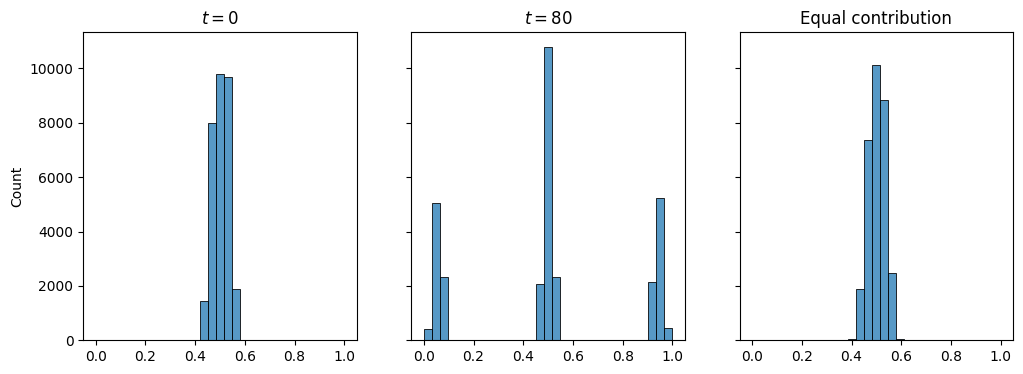

In [7]:
beta_matrix_t0 = sim_clonal.get_methylation_matrix_at_time(0)
counts_t0 = sim_clonal.counts_history[0]
counts_tlast = sim_clonal.counts_history[-1]
beta_matrix_tlast = sim_clonal.get_methylation_matrix_at_time(time_points_clonal[-1])

beta_matrix_t0 = beta_matrix_t0[:, mean_mask]
beta_matrix_tlast = beta_matrix_tlast[:, mean_mask]

counts_synthetic = np.ones_like(counts_t0)
prop = 0.5
counts_synthetic[:int(len(counts_synthetic)*prop)] = 0 # Hypothetical distribution where we've lost `prop` lineages but the others remain equal

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

# === Time 0 of above simulation
averaged_t0 = np.average(beta_matrix_t0,    weights=counts_t0, axis=0).flatten()
sns.histplot(averaged_t0,
             bins=np.linspace(0, 1, 32), ax=ax[0])
ax[0].set_title("$t=0$")

# === Last timepoint of above simulation
averaged_tlast = np.average(beta_matrix_tlast, weights=counts_tlast, axis=0).flatten()
sns.histplot(averaged_tlast,
             bins=np.linspace(0, 1, 32), ax=ax[1])
ax[1].set_title(f"$t={time_points_clonal[-1]}$")

# === Synthetic count distribution
# Note: Assumes 0 variance of a marker within a lineage. How to fix?
averaged_synthetic = np.average(beta_matrix_t0, weights=counts_synthetic, axis=0).flatten()
sns.histplot(averaged_synthetic,
             bins=np.linspace(0, 1, 32), ax=ax[2])
ax[2].set_title("Equal contribution")

sim_var_ratio = np.var(averaged_tlast) / np.var(averaged_t0)
inferred_clonality_sim_stats = infer_clonality_from_variance(averaged_tlast, v_t0=np.var(averaged_t0), N_t0=N)
simpson_hat_sim = inferred_clonality_sim_stats["estimated_simpson"]
estimated_gini_sim = inferred_clonality_sim_stats["estimated_gini"]
estimated_p_max_sim = inferred_clonality_sim_stats["estimated_p_max"]
effective_lineage_count_sim = inferred_clonality_sim_stats["effective_lineage_count"]

print("Last / First (std): ")
print(f" Max clone size: {np.max(counts_tlast) / np.sum(counts_tlast):.3g} (tlast)")
print(f" N. nonzero lineages: {np.count_nonzero(counts_tlast):.3g} (tlast)")
print(f"  Simpson_hat: {simpson_hat_sim:.3g}")
print(f"  1/Simpson_hat: {1/simpson_hat_sim:.3g}")
print(f"  P_max: {estimated_p_max_sim:.3g}")


print("")
print("="*20)
print("")

synth_var_ratio = np.var(averaged_synthetic) / np.var(averaged_t0)
inferred_clonality_synth_stats = infer_clonality_from_variance(averaged_synthetic, v_t0=np.var(averaged_t0), N_t0=N)
simpson_hat_synth = inferred_clonality_synth_stats["estimated_simpson"]
estimated_gini_synth = inferred_clonality_synth_stats["estimated_gini"]
estimated_p_max_synth = inferred_clonality_synth_stats["estimated_p_max"]
effective_lineage_count_synth = inferred_clonality_synth_stats["effective_lineage_count"]
print("Synth. / First (std): ")
print(f" Max clone size: {np.max(counts_synthetic) / np.sum(counts_synthetic):.3g} (synthetic)")
print(f" N. nonzero lineages: {np.count_nonzero(counts_synthetic):.3g} (synthetic)")
print(f"  Simpson_hat: {simpson_hat_synth:.3g}")
print(f"  1/Simpson_hat: {1/simpson_hat_synth:.3g}")
print(f"  P_max: {estimated_p_max_synth:.3g}")
print("")


## Demo 3: Therapy Bottleneck

### Design

| Event | Time | Effect |
|---|---|---|
| Mutant seeded | `t = 5` yr | `p_ss=0.51`, `tau=TAU/2` - mildly fit, fast-cycling |
| Niche collapse | `t = 25` yr | `K *= 0.5` - cytotoxic therapy halves carrying capacity |
| Niche recovery | `t = 35` yr | `K` restored to `K_init` |

Both events are composed in a single `event_fn` by nesting `therapy_hook` inside `setup_hook`. This pattern - chaining hooks by sequential calls inside a wrapper function - is the idiomatic way to combine independent events without subclassing `ClonalSim`.

### What it simulates
A mildly fit mutant (`r ≈ 0.02/yr`) grows slowly through the pre-therapy period. At `t=25`, cytotoxic therapy is modelled as halving the niche capacity `K`. The entire population crashes proportionally - background lineages with low cell counts are most likely to go extinct, but the mutant, having grown for 20 years, is larger and more likely to survive. When `K` is restored at `t=35`, the surviving lineages re-expand to fill the empty niche, with the mutant disproportionately represented.

This reproduces the clinical observation that post-treatment CHIP clones are usually pre-existing clones that survived the bottleneck, not therapy-induced *de novo* mutations.

### What to look for
- A population crash at `t=25` followed by rapid re-expansion in the Muller plot
- The mutant (red) holds or gains share through the bottleneck, then expands further during recovery
- The Gini coefficient spikes at the bottleneck - maximum inequality when only a few clones survive - then partially recovers but does not return to its pre-therapy level
- Diversity lost to the bottleneck (nonzero lineage count) is permanently reduced


In [ ]:
# Therapy bottleneck: K *= 0.1 at t=30, restored at t=35

def therapy_hook(sim, t):
    """Event hook: apply therapy bottleneck at t=30, restore at t=35."""
    dt = float(np.min(sim.tau))
    if abs(t - 25.0) < dt * 0.5:
        sim.K *= 0.5
        print(f"  [t={t:.1f}] Therapy: K reduced to {sim.K:.1f}")
    elif abs(t - 35.0) < dt * 0.5:
        sim.K = sim._K_init
        print(f"  [t={t:.1f}] Recovery: K restored to {sim.K:.1f}")


print(TAU)

sim_therapy = ClonalSim(
    N_init=N,
    K_init=N,
    p_sym_renewal=p_sym_renewal,
    p_asym=p_asym,
    p_diff=p_diff,
    tau=TAU,
    mu=MU,
    division_dist=DIVISION_DIST_GENERATOR,
    symmetry_drift_alpha=1000.0,
)

# Add a mutant with expansion advantage before therapy
def setup_hook(sim, t):
    therapy_hook(sim, t)
    if abs(t - 5.0) < float(np.min(sim.tau)) * 0.5:
        sim.add_lineage(p_ss=0.51, p_sd=0.0, p_dd=0.49,
                        initial_count=1.0,
                        tau=TAU/2, color='#FF0000')
        print(f"  [t={t:.1f}] Mutant seeded (p_ss=0.42)")

sim_therapy.event_fn = setup_hook

time_points_therapy = list([25, 30, 32.5, 40, 50, 70, 85])
results_therapy = sim_therapy.run_simulation(time_points_therapy)

print("Therapy bottleneck simulation complete.")
print(f"  Final time: {sim_therapy.current_time:.1f} years")
plot_lineage_evolution(
    sim=sim_therapy,
    # timepoints_to_evaluate=time_points_therapy,
    min_proportion=1,
    max_lineages=N*2.5,
    shuffle=True,
    figsize=(6, 3)

)
plt.suptitle("Demo 3: Therapy Bottleneck (K*=0.1 at t=30, restored at t=35)")
plt.tight_layout()
plt.show()

In [ ]:
plot_population_metrics(sim_therapy,
                        range(0, 85, 5),
                        metric_specs=[
                            N_over_s_spec,
                            nonzero_spec,
                            gini_spec,
                            max_clone_size,
                            avg_clone_size,
                            avg_nonzero_clone_size],
                        figsize_per_panel=(8, 1.5))


## Demo 4: Nonlinear Growth - Early-Life HSC Pool Expansion

### Design

| Parameter | Birth value | Adult value | Transition |
|---|---|---|---|
| Niche capacity `K` | 25 (= N_FOUNDING) | 1,000 | √t ramp over [0, 15] yr |
| Division time `τ` | 5% of adult | 1.5 yr | Same √t ramp |
| Mutation rate `μ` | 5×10⁻² | 1×10⁻⁶ | Step drop at `expansion_end` |
| Founding lineages | 25 | - | Tagged "original" (gray) |
| Derived lineages | arise stochastically | - | Tagged "derived" (blue/pink) |

All parameter ramping is managed inside the `make_nonlinear_growth_hook` factory, which returns a stateful `event_fn`. The hook fires at every timestep and mutates `sim.K`, `sim.tau[:]`, and `sim.mu[:]` in-place. This demonstrates one of the most powerful uses of the hook API: continuously varying simulation parameters without subclassing.

### What it simulates
At birth, ~25 haemogenic endothelium-derived founder lineages partition the nascent HSC niche. Over the first 15 years the niche expands ~40-fold and HSCs cycle far faster than in adulthood (fetal division times of weeks vs. ~1 year in adults). The elevated `μ` during expansion means new lineages arise frequently, but those born earliest ride the same growth wave as the founders and reach large adult sizes purely through timing and drift - not fitness advantage.

This mirrors empirical findings (Lee-Six *et al.* 2018; Mitchell *et al.* 2022) that most adult CHIP-sized clones can be traced to mutations acquired during fetal expansion rather than mid-life positive selection.

### What to look for
- "Original" (gray) founding lineages that survive to adulthood tend to be the largest
- "Derived" (blue/pink) lineages born early are larger than late-born ones, even though all are neutral
- After `expansion_end = 15` yr, the clone-size distribution largely freezes - little further change without a fitness advantage
- The total pool size follows a √t growth curve up to `K=1,000`, then plateaus at the adult carrying capacity


In [ ]:
# =============================================================================
# Demo 4: Nonlinear Growth Hook
# =============================================================================
#
# Concept
# -------
# The HSC niche is not at steady-state at birth - it expands during childhood
# and reaches carrying capacity around age ~15.  This hook models that by:
#
#   1. Starting with ~50 clones, each seeded with count = K_final / 50.
#   2. Linearly ramping K from a small "birth" value up to K_final over [0, 15].
#   3. Simultaneously tightening tau (faster cell-cycle) as the niche fills, by
#      scaling tau as a fixed fraction of the current K (tau ∝ K / K_final).
#   4. After t >= 15 the system is at capacity; every subsequent mutation-born
#      lineage is tagged "derived", while the founding 50 are tagged "original".
#   5. Coloring: original lineages -> pastel blues/greens,
#                derived lineages  -> pastel pinks/oranges.
#
# Hook signature mirrors therapy_hook: nonlinear_growth_hook(sim, t)
#
# Usage
# -----
#   sim.event_fn = nonlinear_growth_hook
#   (or compose with other hooks - see setup_hook pattern below)

def make_nonlinear_growth_hook(
        K_final: float, K_birth: float,
        tau_final: float,
        expansion_end: float = 15.0,
        tau_birth_fraction: float = 0.3,
        mu_expansion: float = 1e-3,
        mu_adult: float = 1e-6,
):
    """
    Factory that returns a stateful event hook implementing nonlinear niche growth.

    Biological grounding
    --------------------
    During fetal and neonatal hematopoiesis the HSC pool expands ~1000-fold
    from a handful of hemogenic endothelium-derived founders (Lee-Six et al.
    2018, Mitchell et al. 2022, Osorio et al. 2018).  HSCs are predominantly
    cycling - division times of weeks rather than months - so somatic mutations
    accumulate *as a by-product of normal expansion*, not through selection.
    Clones that arise early ride the same symmetric self-renewal wave as the
    founders, reaching large adult sizes purely through timing and drift.  At
    steady-state (~age 20–25 in humans) division rate drops sharply and the
    clone-size distribution freezes.

    This hook models that process directly:

    1. **Elevated mu during expansion** (``mu_expansion``).  Rapid cycling
       means more mutation opportunities per unit time.  No artificial seeding
       is needed - the simulation's own stochastic mutation machinery produces
       derived lineages at count=1, each of which then expands on the same
       logistic growth curve as the founders.

    2. **K and tau ramp together** from birth values to adult values over
       [0, expansion_end].  Low early niche pressure (phi ≈ 1) means even
       neutral mutants expand freely - clonal size at maturity is set
       primarily by birth time and drift.

    3. **At expansion_end**, mu drops to the adult rate (``mu_adult``) and
       tau/K are fixed.  Any lineage born before this point is tagged
       "original" (pastel blue); any born after is "derived" (pastel pink).
       The classification happens automatically each timestep by inspecting
       ``lineage_ages`` against ``expansion_end``.

    Parameters
    ----------
    K_final : float
        Adult carrying capacity of the HSC niche.
    tau_final : float
        Adult HSC division time (years).
    expansion_end : float, default 15.0
        Age (years) at which the niche reaches K_final and cycling slows.
    tau_birth_fraction : float, default 0.3
        tau at t=0 as a fraction of tau_final (~weeks if tau_final=1 yr).
    mu_expansion : float, default 1e-3
        Per-division mutation rate during the expansion phase.  Elevated
        relative to adult rate to reflect rapid neonatal cycling.
    mu_adult : float, default 1e-6
        Per-division mutation rate after expansion_end.

    Returns
    -------
    callable
        An ``event_fn(sim, t)`` suitable for ``ClonalSim.event_fn``.
    """
    tau_birth = tau_final * tau_birth_fraction

    _initialized = [False]

    original_pastels = ["#AAAAAA"]
    derived_pastels = [COLORS_LARGE_PALLETE[0], COLORS_LARGE_PALLETE[4]]

    def _hook(sim, t):
        # ----------------------------------------------------------------
        # One-time initialisation
        # ----------------------------------------------------------------
        if not sim.run_properties['initialized']:
            sim.run_properties['initialized'] = True

            sim.register_class("original", palette=original_pastels)
            sim.register_class("derived",  palette=derived_pastels)

            # Founding lineages (hemogenic endothelium-derived) are "original"
            for lid in list(sim._class_member_order.get("initial", [])):
                sim._assign_lineage_class(lid, "original")
            sim._class_member_order["initial"] = []

            # Set birth-state K, tau, and elevated expansion mu
            sim.K      = K_birth
            sim.tau[:] = tau_birth
            sim.mu[:]  = mu_expansion
            # In the _initialized block, after reclassifying:
            sim.run_properties['original_lids'] = set(sim.lineage_ids)   # exactly the N_FOUNDING founders

            print(f"  [nonlinear_growth] Init: K={sim.K:.1f}, tau={tau_birth:.3f}, "
                  f"mu={mu_expansion:.1e}, {len(sim.counts)} founding lineages")

        # ----------------------------------------------------------------
        # Ramp K and tau during expansion; keep mu elevated
        # ----------------------------------------------------------------
        if t < expansion_end:
            frac  = np.sqrt(t) / np.sqrt(expansion_end)
            sim.K = K_birth + (K_final - K_birth) * frac

            new_tau    = tau_birth + (tau_final - tau_birth) * frac
            sim.tau[:] = new_tau
            sim.mu[:]  = mu_expansion

        else:
            sim.K      = K_final
            sim.tau[:] = tau_final
            sim.mu[:]  = mu_adult

        # Then in the classification loop:
        for lid, age in zip(sim.lineage_ids, sim.lineage_ages):
            target_class = "original" if lid in sim.run_properties['original_lids'] else "derived"
            if sim.lineage_classes.get(lid) != target_class:
                sim._assign_lineage_class(lid, target_class)

    return _hook


N_FOUNDING   = 25
K_FINAL      = 1000.0
TAU_FINAL    = 1.5
P_SYM        = 0.475
P_ASYM       = 0.05
P_DIFF       = 0.475
MU           = 0.5      # elevated to see derived lineages appear
EXPANSION_END = 15.0

growth_hook = make_nonlinear_growth_hook(
    K_final=K_FINAL, K_birth=N_FOUNDING,
    tau_final=TAU_FINAL,
    expansion_end=EXPANSION_END,
    tau_birth_fraction=0.05,
    mu_expansion=5e-2,
    mu_adult=1e-6,
)

sim_growth = ClonalSim(
    N_init=N_FOUNDING,
    K_init=N_FOUNDING,   # initial K (hook will set this too)
    p_sym_renewal=P_SYM,
    p_asym=P_ASYM,
    p_diff=P_DIFF,
    tau=TAU_FINAL * 0.05,             # initial tau (hook will manage)
    mu=MU,
    division_dist=DIVISION_DIST_GENERATOR,
    symmetry_drift_alpha=1000.0,
    event_fn=growth_hook,
)

sim_growth.run_properties['initialized'] = False

time_points = [5, 10, 15, 20, 30, 50, 70]
results_growth = sim_growth.run_simulation(time_points)

print("\nNonlinear growth simulation complete.")
print(f"  Final time : {sim_growth.current_time:.1f} years")
n_orig    = len(sim_growth._class_member_order.get("original", []))
n_derived = len(sim_growth._class_member_order.get("derived",  []))
print(f"  Original lineages : {n_orig}")
print(f"  Derived  lineages : {n_derived}")

# ---- plot ---------------------------------------------------------------
try:
    fig, axes = plot_lineage_evolution(
        sim=sim_growth,
        min_proportion=1,
        max_lineages=10000,
        shuffle=False,
        figsize=(6, 3),
    )
except Exception:
    # plot_lineage_evolution may not be defined in all versions of the file
    fig, ax = plt.subplots(figsize=(8, 4))
    t_arr = np.array(sim_growth.time_history)
    ch = np.array(sim_growth.counts_history, dtype=object)
    total = np.array([np.sum(c) for c in ch])
    ax.plot(t_arr, total, lw=2, color="#4C78A8", label="Total HSC pool")
    ax.axvline(EXPANSION_END, color="gray", ls="--", lw=1, label="Capacity age")
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Total cells")
    ax.legend()

plt.suptitle("Demo 4: Nonlinear Growth - Original (pastel blue) vs Derived (pastel pink)")
plt.tight_layout()
print("  Plot saved -> demo4_nonlinear_growth.png")
plt.show()
plt.style.use('default')


### Demo 4 Takeaways

**Early-life expansion is the dominant determinant of adult clone-size diversity - without requiring any selection.** Key observations:

- **Timing beats fitness.** A neutral lineage born at `t=1` yr will, on average, be `√(15/1) ≈ 3.9×` larger at maturity than one born at `t=15` yr, purely because it expanded for longer before the niche filled. No fitness advantage is needed to produce a "large" adult clone.
- **Most large adult clones are fetal in origin.** This is consistent with phylogenetic reconstruction of blood lineage trees (Lee-Six *et al.* 2018; Mitchell *et al.* 2022), which show that the branching pattern of adult HSC phylogenies fits a rapid early expansion rather than mid-life selection for the majority of CHIP-sized clones.
- **The μ step-drop is biologically motivated.** Rapid fetal cycling (low τ) means more divisions per unit time and therefore more somatic mutations per year. After the niche reaches steady-state, the adult rate (μ=10⁻⁶) means new variants arise far less frequently, and the clone-size distribution largely freezes.
- **Implication for CHIP detection.** A large clone in an elderly individual does not automatically imply recent positive selection. It may simply be an early-fetal lineage that has coasted on its head-start for seven decades. Distinguishing drift-inflated ancient clones from recently selected ones requires either variant-based phylogenetics or a methylation-clock model that tracks the age-trajectory of variance across a cohort - which is precisely what is built in Notebook 02.


## Demo 5: Genomic Instability — Elevated Mutation Rate and Reduced Sojourn Time

### Design

| Parameter | Background | Unstable mutant |
|---|---|---|
| `p_ss / p_dd` | 0.50 / 0.50 | 0.52 / 0.48 |
| `μ` | 0 | 5×10⁻⁴ |
| `τ` (sojourn time) | 0.75 yr | 0.19 yr (~4× faster) |
| Seeded at | — | `t = 10` yr |

The event hook fires at `t = 10` yr and passes both `mu=MU_UNST` and `tau=TAU_UNST` directly to `add_lineage`. These two parameters act through independent mechanisms that compound each other:

- **Elevated `μ`** increases the number of new subclone-generating mutations *per division*. Each cell division is a lottery ticket; more tickets means more winners.
- **Reduced `τ`** increases the number of divisions *per unit time*. The unstable lineage runs through more cell cycles per year than background lineages, so it accumulates mutations faster and its clone size grows faster for any given `p_ss / p_dd`.

Together, the effective per-year mutation output scales as `μ / τ`: halving `τ` doubles the annual mutation rate independently of `μ`. The division probabilities (`p_ss`, `p_dd`) then determine which of those mutations sweep — both axes of advantage (rate and selection) are orthogonal, making genomic instability a multiplicative risk amplifier without requiring any special fitness distribution for subclones.

### What to look for
- The unstable mutant (pink) expands faster than a normal clone with the same `p_ss / p_dd` would, purely due to the shorter sojourn time
- A burst of subclones (thin wedges) appears shortly after `t = 10` as the elevated `μ / τ` generates new variants rapidly
- The Gini coefficient accelerates after seeding — driven by the compounding of faster cycling and higher mutation supply
- Total population remains bounded by `K`: the niche is zero-sum

In [ ]:
from src.simulation_plotting import N_over_s_spec, nonzero_spec, gini_spec

# -------------------------------------------------------------------------
# Demo 5 Parameters
# -------------------------------------------------------------------------
TAU_5     = 0.75          # Background sojourn time (years)
TAU_UNST  = TAU_5 / 4    # Unstable mutant: ~4x faster cycling
N_5       = 1000
MU_BG_5   = 0            # Background: no spontaneous mutations
MU_UNST   = 5e-4         # Unstable mutant: elevated mutation rate
P_SS_5    = 0.52
P_DD_5    = 0.48


def make_instability_hook(seed_time: float = 10.0):
    """
    Event hook for genomic instability.

    At seed_time, injects an unstable lineage with:
      - mu=MU_UNST  : elevated per-division mutation rate
      - tau=TAU_UNST: reduced sojourn time (faster cycling)

    The two parameters act through independent mechanisms: mu scales
    mutations per division, tau scales divisions per year.  Their combined
    effect on annual mutation output is mu / tau — orthogonal to the
    division-probability fitness (p_ss - p_dd).
    """
    seeded = [False]

    def _hook(sim, t):
        dt = float(np.min(sim.tau)) if sim.dt is None else sim.dt
        if abs(t - seed_time) < dt * 0.5 and not seeded[0]:
            seeded[0] = True

            lid = sim.add_lineage(
                p_ss=P_SS_5, p_sd=0.0, p_dd=P_DD_5,
                initial_count=5.0,
                tau=TAU_UNST,
                mu=MU_UNST,
                color='#E84393',   # hot pink = genomically unstable lineage
            )
            print(f"  [t={t:.1f}] Unstable mutant added "
                  f"(id={lid}, mu={MU_UNST:.1e}, tau={TAU_UNST:.2f})")

    return _hook


sim_unstable = ClonalSim(
    N_init=N_5,
    adata=methylation_adata,
    p_sym_renewal=p_sym_renewal,
    p_asym=p_asym,
    p_diff=p_diff,
    tau=TAU_5,
    mu=MU_BG_5,
    division_dist=DIVISION_DIST_GENERATOR,
    symmetry_drift_alpha=1000.0,
    max_variants=50,
    event_fn=make_instability_hook(seed_time=10.0),
)

time_points_unstable = list(range(5, 85, 5))
results_unstable = sim_unstable.run_simulation(time_points_unstable)

print("Genomic instability simulation complete.")
print(f"  Final time: {sim_unstable.current_time:.1f} years")
print(f"  Total lineages (incl. subclones): {len(sim_unstable.lineage_ids)}")

plt.style.use('default')
plot_lineage_evolution(
    sim=sim_unstable,
    min_proportion=0,
    max_lineages=N_5 * 10,
    shuffle=True,
    figsize=(6, 3),
)
plt.suptitle("Demo 5: Genomic Instability (μ=5×10⁻⁴, τ=TAU/4 — elevated mutation rate + faster cycling)")
plt.tight_layout()
plt.show()

plot_population_metrics(
    sim_unstable,
    range(0, 85, 5),
    metric_specs=[N_over_s_spec, nonzero_spec, gini_spec, max_clone_size],
    figsize_per_panel=(5, 2),
)
plt.show()

### Demo 5 Takeaways

**Genomic instability amplifies clonal risk through two orthogonal axes — mutation supply and cycling speed — without requiring any special fitness distribution for subclones.** Key observations:

- **`μ` and `τ` act independently but compound.** Annual mutation output scales as `μ / τ`: the unstable lineage here has `μ` raised ~4 orders of magnitude and `τ` reduced 4-fold, giving it roughly `4 × 10⁴×` more new variants per year than a background lineage. Neither change touches `p_ss / p_dd`; they operate through an entirely separate axis of the model.
- **Reduced `τ` accelerates the clone itself, not just its subclones.** A shorter sojourn time means more symmetric self-renewal events per year, so the unstable lineage expands faster than a clone with the same `p_ss / p_dd` on the background `τ`. This mirrors the rapid proliferation of CIN or MMR-deficient cells in early malignancy.
- **Subclone fitness is drawn from the default distribution.** No special sampler is needed — the elevated `μ / τ` simply supplies more raw material for selection to act on. Occasional high-fitness draws from the background `division_dist` then sweep and dominate, producing the "spiralling" effect through ordinary clonal dynamics.
- **Niche capacity remains the hard constraint.** Total cell count is bounded by `K`; the instability shifts *who* fills the niche, not how large the niche is.
- **Clinical implication.** CIN and MMR-deficient tumours are aggressive not because any single mutation is unusually fit, but because the elevated mutation supply generates more driver candidates per unit time. This demo shows that recapitulating that biology requires only two parameter changes to a single lineage — no new model machinery needed.

---

## Transition: Realistic Single-Individual Simulation

Demos 1–4 used a simplified, single-level initialization: each lineage's methylation was drawn independently from the population-level Beta posterior. This is fast for demos but conflates *population* variability with *within-individual* variability - every lineage inside the same person ends up as dispersed as people across the whole cohort.

Notebook 02 corrects this with three changes, reproduced here for a single individual:

**1. CpG selection**
Rather than all ~750k CpGs or random subsets, we select **1,000 sites** from GenScot stratified by mean methylation (0.15–0.85) and ranked within each bin by the largest age-related variance increase. These are the sites most likely to carry a detectable clonality signal.

**2. Two-level hierarchical methylation initialization**
- *Population -> Individual:* one individual-level mean drawn from the GenScot population Beta posterior
- *Individual -> Lineage:* each of the 10,000 lineages draws from a tighter Beta centred on that individual's mean (within-individual precision φ=250)

**3. Empirical mutant fitness from LiFT**
Instead of a fixed `p_ss`, each new mutant's division probabilities are drawn from a Beta distribution fitted to the LiFT (Large-scale Identification of Fitness effects from Tree-based analysis) dataset - the empirical distribution of somatic fitness effects measured in human HSCs.

### Step 1: CpG Selection, Model Restriction, and LiFT Fitness


In [ ]:
from scipy.stats import beta as beta_dist

# --- Step 1a: Select 1000 CpGs from GenScot ---
# Stratified by mean methylation (0.15–0.85), ranked within each bin by largest
# age-related variance increase - the sites most likely to carry a clonality signal.
N_POP_CPG = 1000
bins = 20
per_bin = round(N_POP_CPG / bins)
bin_edges = np.linspace(0.15, 0.85, bins + 1)

# Evaluate model at age boundaries to measure age-related precision change
X_bounds = np.array([
    [1.0, (18 - 13.5) / (122.5 - 13.5), 0.0, 0.5],   # ~age 18
    [1.0, (90 - 13.5) / (122.5 - 13.5), 0.0, 0.5],   # ~age 90
])
moments_bounds = model.predict_moments(X_bounds, X_bounds)
delta_precision = moments_bounds['phi'][1] - moments_bounds['phi'][0]  # negative = variance increases with age

idx_all = np.arange(len(delta_precision))
selected_indices = []
for i in range(bins):
    lo, hi = bin_edges[i], bin_edges[i + 1]
    mask = (moments_bounds['mean'][0] >= lo) & (moments_bounds['mean'][0] < hi)
    bin_idx = idx_all[mask]
    n_sample = min(per_bin, len(bin_idx))
    if n_sample > 0:
        order = np.argsort(delta_precision[mask])        # most negative (largest variance increase) first
        selected_indices.append(bin_idx[order[:n_sample]])

selected_indices = np.concatenate(selected_indices)
assert len(np.unique(selected_indices)) == len(selected_indices), "duplicate CpG indices"
selected_cpgs = genscot_regression_df.iloc[selected_indices].index

print(f"Selected {len(selected_indices)} CpGs from {len(genscot_regression_df):,} total")
print(f"  Mean range        : [{moments_bounds['mean'][0][selected_indices].min():.2f}, "
      f"{moments_bounds['mean'][0][selected_indices].max():.2f}]")
print(f"  Δprecision range  : [{delta_precision[selected_indices].min():.1f}, "
      f"{delta_precision[selected_indices].max():.1f}]")

# --- Step 1b: Restrict model to selected CpGs ---
pop_model = BetaRegressionAlphaBeta()
pop_model.gamma_alpha = [model.gamma_alpha[i][selected_indices] for i in range(4)]
pop_model.gamma_beta  = [model.gamma_beta[i][selected_indices]  for i in range(4)]

# --- Step 1c: LiFT empirical fitness distribution for mutant division probabilities ---
lift_df = pd.read_csv('./data/LiFT_Fitness_Effects.txt', sep='\t')
lift_fitness = lift_df['Fitness'].values
lift_params = beta_dist.fit(lift_fitness)
lift_generator = beta_dist(*lift_params)

def fitness_to_division_probs(s_gen, lambda_div=1.3, p_as=0.0):
    s = s_gen()
    sym = 1.0 - p_as
    delta = s / lambda_div
    return np.array([sym / 2 + delta / 2, 0.0, sym / 2 - delta / 2], dtype=np.float32)

lift_division_generator = partial(fitness_to_division_probs, lift_generator.rvs)

sns.histplot(lift_fitness, bins=32, color='steelblue')
plt.xlabel('Fitness effect (s)')
plt.title('LiFT empirical fitness distribution (Beta fit)')
plt.show()


### Step 2: Two-Level Hierarchical Methylation Initialization

Before building the `ClonalSim`, we need a starting methylation matrix that reflects biological reality. Methylation variability exists at two distinct levels:

| Level                        | Distribution | What it captures |
|------------------------------|---|---|
| **Population -> Individual** | `μ_ind ~ Beta(α_pop, β_pop)` | Person-to-person CpG variation |
| **Individual -> Lineage**    | `p_lineage ~ Beta(μ_ind · φ, (1−μ_ind) · φ)`, φ=250 | Within-person clonal heterogeneity |

Each lineage probability is then converted to a diploid methylation state {0, 0.5, 1} via Hardy-Weinberg sampling, matching the conventions of the GenScot array data.

The simulation is always initialized at **maturity** (age 13.5 -> `t_linear=0`, `t_power=0`) and run forward to the target age. The individual's age-at-sampling emerges from the dynamics rather than being baked into the initial condition.


In [ ]:
N_POP_LINEAGES = 10000

def sample_lineage_methylation(alphas_pop, betas_pop, n_lineages, phi_within=250.0):
    """Two-level hierarchical Beta sampling.

    Level 1: draw this individual's mean CpG profile from the population posterior.
    Level 2: draw each lineage's probability from a tighter Beta around that mean.
    """
    mu_individual = np.random.beta(alphas_pop, betas_pop)
    alpha_ind = np.clip(mu_individual * phi_within, 1e-3, None)
    beta_ind  = np.clip((1.0 - mu_individual) * phi_within, 1e-3, None)
    lineage_probs = np.random.beta(
        alpha_ind[None, :], beta_ind[None, :],
        size=(n_lineages, len(alphas_pop))
    )
    return lineage_probs, mu_individual


def transition_generator_fn(mean_beta, variance=0.05, total_rate=0.05):
    """Per-division methylation transition probabilities with Gaussian jitter on the CpG mean."""
    sampled = np.clip(np.random.normal(mean_beta, np.sqrt(variance)), 0, 1)
    return sampled * total_rate, (1.0 - sampled) * total_rate


# Initialize at sexual maturity: t_linear=0, t_power=0, sex=0.5 (population average)
X_maturity = np.array([[1.0, 0.0, 0.0, 0.5]])
moments_init = pop_model.predict_moments(X_maturity, X_maturity)

lineage_probs, mu_individual = sample_lineage_methylation(
    moments_init['alpha'][0], moments_init['beta'][0],
    n_lineages=N_POP_LINEAGES, phi_within=250.0
)

# generate_diploid_methylation_states returns (n_cells, n_lineages, n_cpg); take the single cell slice
diploid_init = generate_diploid_methylation_states(
    lineage_probs, distribution_func=hardy_weinberg_probabilities, n_cells=1
)[0]  # shape: (N_POP_LINEAGES, N_POP_CPG)

adata_demo = anndata.AnnData(
    X=diploid_init.astype(np.float16),
    obs=pd.DataFrame(index=[str(i) for i in range(diploid_init.shape[0])]),
    var=pd.DataFrame(index=selected_cpgs),
)

print(f"Initialized methylation matrix:")
print(f"  Shape         : {adata_demo.shape}  (lineages × CpGs)")
print(f"  Individual μ  : [{mu_individual.min():.3f}, {mu_individual.max():.3f}]")
print(f"  Diploid states: {np.mean(diploid_init == 0):.1%} unmethylated  "
      f"| {np.mean(diploid_init == 0.5):.1%} heterozygous  "
      f"| {np.mean(diploid_init == 1.0):.1%} methylated")
adata_demo


In [ ]:
DEMO_AGE = 70
N_POP_LINEAGES = 10000
K_POP = 20000
TAU_POP = 1.3

cpg_means_demo = np.mean(adata_demo.X.astype(np.float32), axis=0)
cpg_types_demo = np.array(['clonal_marker'] * N_POP_CPG)
transition_gen = partial(transition_generator_fn, variance=0.05, total_rate=0.05)

sim_pop = ClonalSim(
    N_init=N_POP_LINEAGES,
    K_init=K_POP,
    counts_init=K_POP / N_POP_LINEAGES,
    adata=adata_demo,
    mu=5 / K_POP,
    p_sym_renewal=0.5,
    p_asym=0.0,
    p_diff=0.5,
    transition_generator=transition_gen,
    division_dist=lift_division_generator,
    cpg_types=cpg_types_demo,
    cpg_means=cpg_means_demo,
    tau=TAU_POP,
    max_variants=None,
)
sim_pop.verbose = True

timepoints = [5, 10, 20, 35, 50, 65, DEMO_AGE]
results_pop = sim_pop.run_simulation(timepoints)

vafs = sim_pop.get_lineage_vafs(background_class='initial')
print(f"\nSimulation complete ({DEMO_AGE}-year-old individual)")
if vafs:
    print(f"  Non-background lineages : {len(vafs)}")
    print(f"  Largest clone VAF       : {max(vafs.values()):.4f}")
else:
    print("  No clonal expansions detected")


In [ ]:
plot_lineage_evolution(sim_pop, min_proportion=1, max_lineages=N_POP_LINEAGES, figsize=(6, 3), shuffle=True)
plt.suptitle(f"Population-initialized simulation - individual age {DEMO_AGE}")
plt.tight_layout()
plt.show()

bm = sim_pop.get_bulk_methylation()
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

sns.histplot(mu_individual, bins=40, ax=ax[0], color='steelblue')
ax[0].set_xlabel('CpG mean methylation (individual-level draw)')
ax[0].set_title('Per-CpG individual mean (population-level Beta draw)')

sns.histplot(bm, bins=np.linspace(0, 1, 41), ax=ax[1], color='salmon')
ax[1].set_xlabel('Bulk methylation β')
ax[1].set_title(f'Bulk methylation at t={DEMO_AGE} years')

plt.tight_layout()
plt.show()
